<br/>
<img src="images/LOGO-CORREO_x.png" alt="SkillNest" width="280px" align="left"/>
<img src="images/LOGO-CORREO_x.png" alt="SkillNest" width="280px" align="right"/>
<div align="center">
<h2>Bootcamp Data Science — Módulo 2</h2><br/>
<h1>Semana 7 · Miércoles — Decision Tree y Random Forest Classifier</h1>
<h3>Modelos basados en árboles para clasificación</h3>
<br/>
    <b>Instructor:</b> Jesús Ortiz · jesus.jeduardo7@gmail.com<br/><br/>
    <b>SkillNest · b2b-sonda-data-science</b>
</div>
<br/>

## 🎯 Objetivos de hoy

1. Entender cómo un **Decision Tree** clasifica con reglas if/else.
2. Visualizar el árbol con `plot_tree` (interpretabilidad real).
3. Controlar el overfitting con `max_depth`, `min_samples_leaf`, `min_samples_split`.
4. Usar **Random Forest Classifier** para mejorar precisión.
5. Extraer y comunicar **Feature Importance** al negocio.
6. Resolver **2 ejercicios profundos** (Titanic + Pima Diabetes).

# 1. Decision Tree Classifier — clasificar con preguntas

### 🧠 La idea

Un árbol de decisión clasifica haciendo **una secuencia de preguntas binarias** sobre las features. En cada nodo se elige la pregunta que mejor SEPARA las clases.

Ejemplo (Titanic):
- *¿Es mujer?* → Sí → **probablemente sobrevivió**
- *¿Es mujer?* → No → *¿Tiene < 15 años?* → Sí → sobrevivió
                                          → No → *¿Pclass = 1?* → ... etc.

El árbol APRENDE qué pregunta hacer en cada nivel para minimizar la **impureza** (Gini o Entropy).

### Parámetros que controlan el overfitting

| Parámetro | ¿Qué hace? | Típico |
|---|---|---|
| `max_depth` | Profundidad máxima del árbol | 3-10 |
| `min_samples_split` | Mínimo de muestras para hacer un split | 2-20 |
| `min_samples_leaf` | Mínimo de muestras en una hoja | 1-10 |
| `criterion` | `'gini'` (default) o `'entropy'` | 'gini' |

### Ventajas vs KNN

| Aspecto | KNN | Decision Tree |
|---|---|---|
| Necesita escalar | ✅ Sí | ❌ No (compara umbrales) |
| Maneja categóricas | ❌ Solo numéricas | ✅ Tras encoding sí |
| Interpretabilidad | Baja | **Alta** (visualizable) |
| Velocidad predict | Lento (busca vecinos) | Muy rápido |

## 👀 Demo en vivo — DT sobre Titanic

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

# Titanic clásico
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)
print(f'Shape: {df.shape}')
print(f'Sobrevivientes: {df["Survived"].value_counts().to_dict()}')
df.head()

Shape: (891, 12)
Sobrevivientes: {0: 549, 1: 342}


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
# Limpieza rápida — eliminar columnas que no aportan o son IDs
df = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])  # Cabin tiene 77% nulos

X = df.drop(columns=['Survived'])
y = df['Survived']

cols_num = ['Age', 'SibSp', 'Parch', 'Fare']
cols_cat = ['Pclass', 'Sex', 'Embarked']

# Pipeline con imputación + encoding
preproc = ColumnTransformer([
    ('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())]), cols_num),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')), ('oh', OneHotEncoder(handle_unknown='ignore'))]), cols_cat)
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
print(f'Train: {X_train.shape} | Test: {X_test.shape}')

Train: (623, 7) | Test: (268, 7)


In [3]:
pipe_dt = Pipeline([('prep', preproc), ('mod', DecisionTreeClassifier(max_depth=4, random_state=42))])
pipe_dt.fit(X_train, y_train)

,steps,"[('prep', ...), ('mod', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [5]:
y_pred = pipe_dt.predict(X_test)

In [ ]:
# Decision Tree con profundidad controlada
print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print(classification_report(y_test, y_pred, target_names=['Murió', 'Sobrevivió']))

Accuracy: 0.7985
              precision    recall  f1-score   support

       Murió       0.78      0.95      0.85       165
  Sobrevivió       0.87      0.56      0.68       103

    accuracy                           0.80       268
   macro avg       0.82      0.75      0.77       268
weighted avg       0.81      0.80      0.79       268



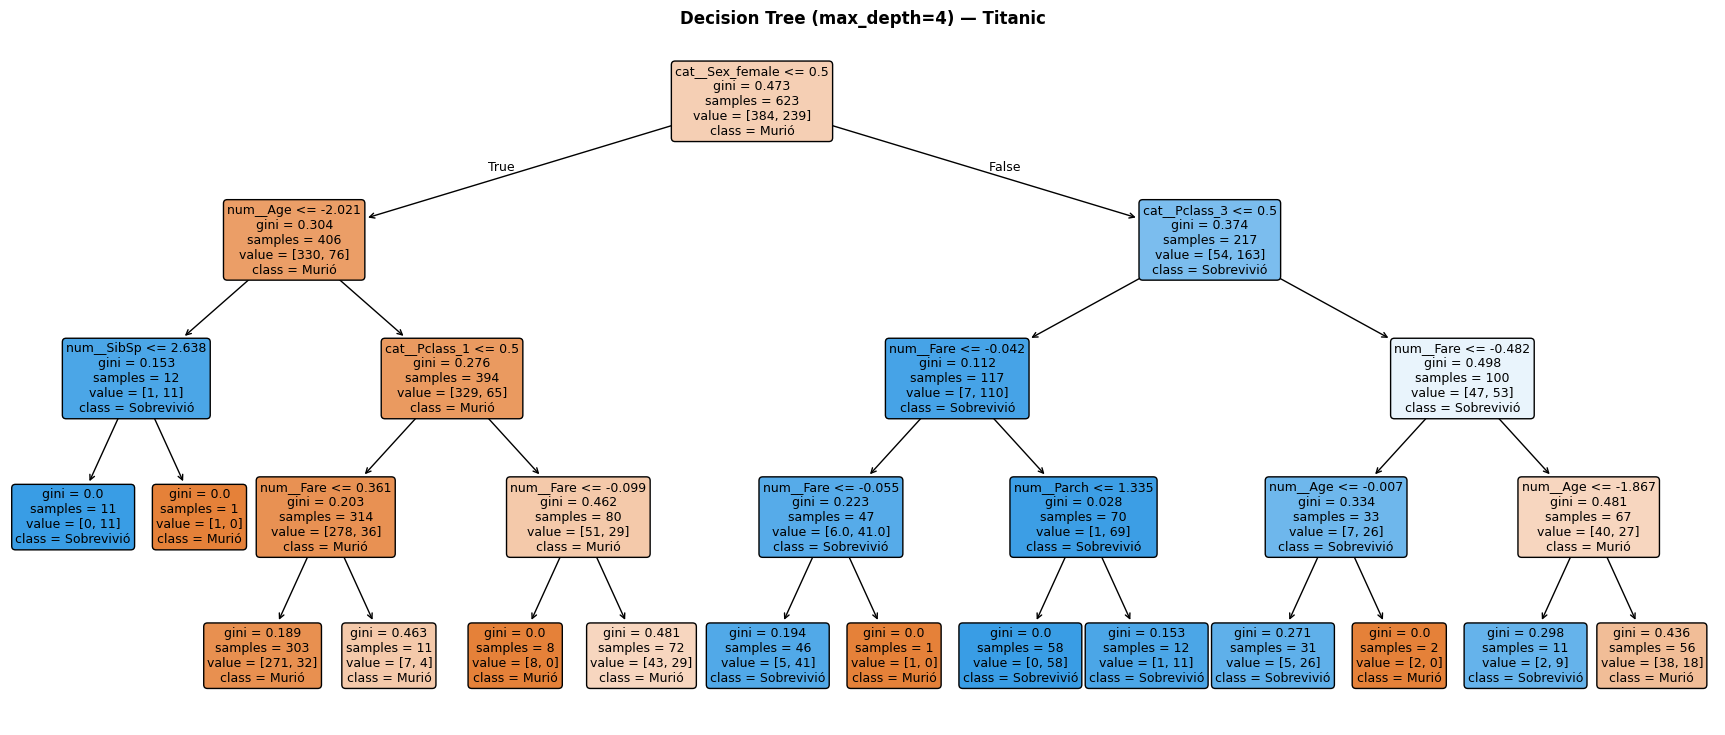

👉 Lee el árbol de arriba a abajo. La primera variable elegida suele ser SEX (machismo total en los botes salvavidas — mujeres y niños primero).


In [6]:
# 🌳 Visualizar el árbol — el superpoder de los DT
nombres = pipe_dt.named_steps['prep'].get_feature_names_out()
fig, ax = plt.subplots(figsize=(22, 9))
plot_tree(pipe_dt.named_steps['mod'],
          feature_names=nombres,
          class_names=['Murió', 'Sobrevivió'],
          filled=True, rounded=True, fontsize=9, ax=ax)
plt.title('Decision Tree (max_depth=4) — Titanic', fontweight='bold')
plt.show()
print('👉 Lee el árbol de arriba a abajo. La primera variable elegida suele ser SEX (machismo total en los botes salvavidas — mujeres y niños primero).')

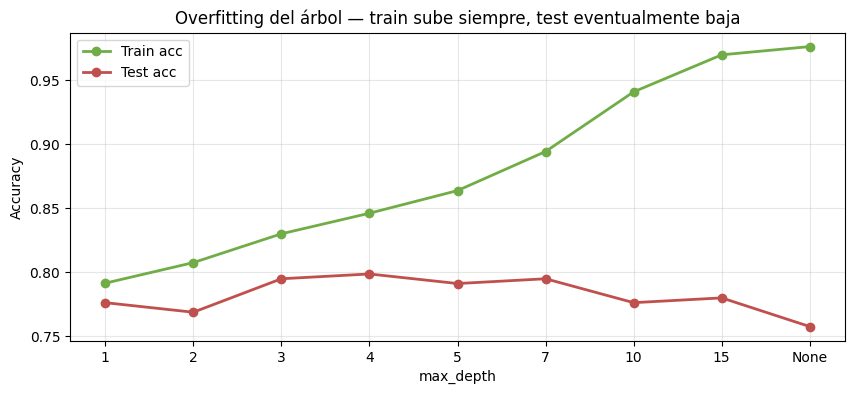

In [7]:
# Ver el overfitting al aumentar profundidad
depths = [1, 2, 3, 4, 5, 7, 10, 15, None]
tr, te = [], []
for d in depths:
    p = Pipeline([('prep', preproc), ('mod', DecisionTreeClassifier(max_depth=d, random_state=42))]).fit(X_train, y_train)
    tr.append(p.score(X_train, y_train))
    te.append(p.score(X_test, y_test))

fig, ax = plt.subplots(figsize=(10, 4))
x_labels = [str(d) if d else 'None' for d in depths]
ax.plot(x_labels, tr, marker='o', linewidth=2, color='#70AD47', label='Train acc')
ax.plot(x_labels, te, marker='o', linewidth=2, color='#C0504D', label='Test acc')
ax.set_xlabel('max_depth'); ax.set_ylabel('Accuracy')
ax.set_title('Overfitting del árbol — train sube siempre, test eventualmente baja')
ax.legend(); ax.grid(alpha=0.3); plt.show()

# 2. Random Forest Classifier — combinar muchos árboles

Mismo concepto que vimos en regresión (semana 6): **muchos árboles entrenados sobre muestras aleatorias** + **selección aleatoria de features** por split → predicción por **voto mayoritario**.

Las ventajas son las mismas:
- ✅ Menos overfitting que un solo árbol
- ✅ Maneja muchas features sin problema
- ✅ Da `predict_proba()` (probabilidad por clase)
- ✅ Feature Importance integrada

In [8]:
pipe_rf = Pipeline([('prep', preproc),
                     ('mod', RandomForestClassifier(n_estimators=200, max_depth=10,
                                                     random_state=42, n_jobs=-1))]).fit(X_train, y_train)

y_pred_rf = pipe_rf.predict(X_test)
print(f'Accuracy RF: {accuracy_score(y_test, y_pred_rf):.4f}')
print(classification_report(y_test, y_pred_rf, target_names=['Murió', 'Sobrevivió']))

# Comparación
print('\n🥊 Decision Tree vs Random Forest:')
print(f'  DT (depth=4):  acc = {pipe_dt.score(X_test, y_test):.4f}')
print(f'  RF (200 árb):  acc = {pipe_rf.score(X_test, y_test):.4f}')

Accuracy RF: 0.8246
              precision    recall  f1-score   support

       Murió       0.83      0.90      0.86       165
  Sobrevivió       0.81      0.71      0.76       103

    accuracy                           0.82       268
   macro avg       0.82      0.80      0.81       268
weighted avg       0.82      0.82      0.82       268


🥊 Decision Tree vs Random Forest:
  DT (depth=4):  acc = 0.7985
  RF (200 árb):  acc = 0.8246


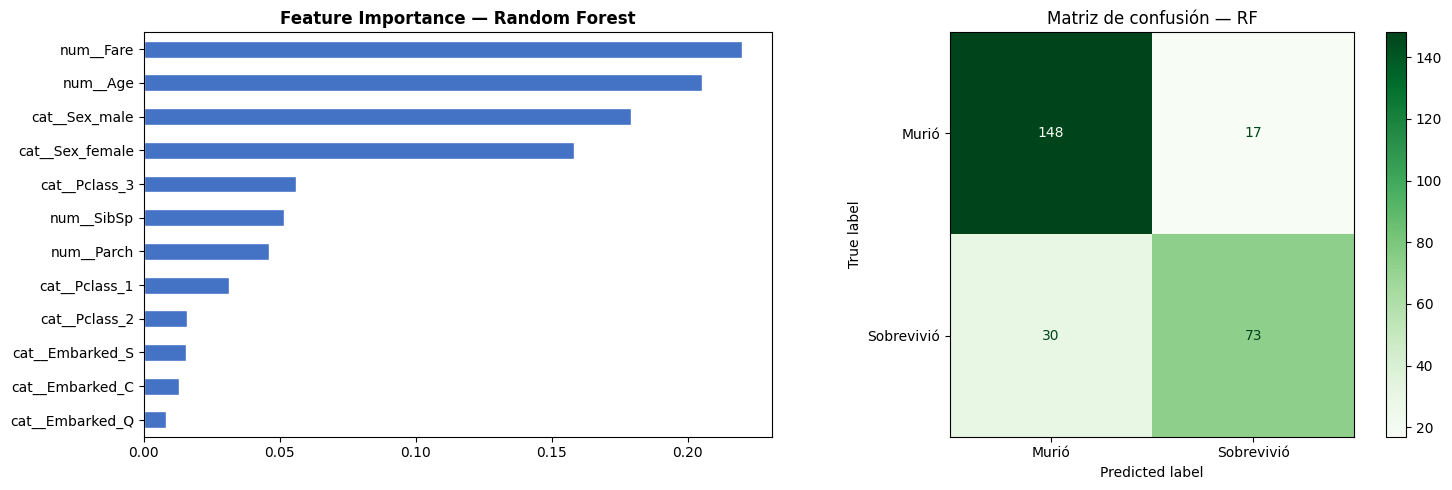

👉 La feature más importante suele ser Sex_male o Fare. Tiene sentido histórico:
   las mujeres tenían prioridad en los botes; los de 1ra clase pagaban más y estaban más cerca de la cubierta.


In [9]:
# Feature Importance — qué variables dominan
nombres = pipe_rf.named_steps['prep'].get_feature_names_out()
imp = pd.Series(pipe_rf.named_steps['mod'].feature_importances_, index=nombres).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
imp.plot(kind='barh', color='#4472C4', edgecolor='white', ax=axes[0])
axes[0].set_title('Feature Importance — Random Forest', fontweight='bold')

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, ax=axes[1], cmap='Greens',
                                         display_labels=['Murió', 'Sobrevivió'])
axes[1].set_title('Matriz de confusión — RF')
plt.tight_layout(); plt.show()

print('👉 La feature más importante suele ser Sex_male o Fare. Tiene sentido histórico:')
print('   las mujeres tenían prioridad en los botes; los de 1ra clase pagaban más y estaban más cerca de la cubierta.')

---
# 🏋️ Ejercicios profundos

## 🚢 Ejercicio 1 — Titanic: árbol vs forest + tuning + interpretación

Vamos a profundizar en el Titanic con un análisis completo.

**Setup:** mismo Titanic ya cargado.

**Parte A — Decision Tree controlado**
1. Entrenar DT con `max_depth=3` y reportar accuracy + classification_report.
2. **Visualizar** el árbol con `plot_tree`. Identificar la **regla principal** (qué pregunta hace primero).
3. Aumentar a `max_depth=None` (sin límite). ¿Sobreajusta? Compara train vs test.

**Parte B — Tuning del DT con GridSearchCV**
4. GridSearchCV con cv=5 sobre:
   - `max_depth`: [3, 5, 7, 10]
   - `min_samples_leaf`: [1, 5, 10]
   - `criterion`: ['gini', 'entropy']
5. Reportar mejores hiperparámetros + métricas en test.

**Parte C — Random Forest + Feature Importance**
6. Entrenar RF con 200 árboles.
7. Comparar accuracy vs el mejor DT.
8. **Top 5 features más importantes** según el RF.
9. ¿Tienen sentido histórico? Explica al menos 2.

**Parte D — Predecir una persona inventada**
10. Predecir si estos 2 pasajeros sobrevivirían (con probabilidades):
    ```python
    pax = pd.DataFrame([
        {'Pclass': 1, 'Sex': 'female', 'Age': 30, 'SibSp': 0, 'Parch': 0, 'Fare': 80,  'Embarked': 'C'},
        {'Pclass': 3, 'Sex': 'male',   'Age': 25, 'SibSp': 0, 'Parch': 0, 'Fare': 8,   'Embarked': 'S'}
    ])
    ```
11. Comentar los resultados — ¿hay diferencia de probabilidad entre los 2 pasajeros?

**Parte E — Matriz de confusión + análisis de errores**
12. Mostrar la matriz del RF.
13. ¿Cuál clase es más difícil de predecir? ¿Por qué crees que ocurre?

In [ ]:
# Parte A — Decision Tree controlado + visualización 👇



In [ ]:
# Parte B — GridSearchCV del DT 👇



In [ ]:
# Parte C — Random Forest + Feature Importance 👇



In [ ]:
# Parte D + E — Predicción + matriz de confusión + análisis 👇



## 🩺 Ejercicio 2 — DT y RF sobre Pima Diabetes (con interpretabilidad)

Volvemos a Pima Diabetes que ya conoces bien, pero ahora con árboles. La idea es comparar la **interpretabilidad** del DT contra la **precisión** del RF.

**Dataset:** Pima Indians Diabetes (mismo de ayer, con limpieza de ceros).

**Parte A — Árbol pequeño y EXPLICABLE**
1. Entrenar un DT con `max_depth=3` (el más pequeño que da información útil).
2. Visualizarlo con `plot_tree`.
3. **Escribe en lenguaje natural** las 2 reglas más importantes (ej. "si Glucose > 130 y BMI > 30, entonces diabetes con 80% probabilidad").

**Parte B — RF + tuning**
4. GridSearchCV con cv=5 sobre RF:
   - `n_estimators`: [100, 200, 500]
   - `max_depth`: [5, 10, None]
   - `min_samples_leaf`: [1, 5]
   - **scoring='f1'** (clases desbalanceadas, ayer aprendimos por qué).
5. Reportar mejores hiperparámetros + métricas en test.

**Parte C — Importancia de variables**
6. Top 8 features según el RF.
7. ¿La variable #1 coincide con lo que un médico esperaría? (Pista: glucose es el indicador principal de diabetes en la vida real)

**Parte D — Comparación con el KNN de ayer**
8. Comparar accuracy, precision, recall y F1 entre KNN (k=11) y el mejor RF.
9. ¿Quién ganó? ¿Por qué?

**Parte E — Decisión clínica**
10. Si fueras el director del hospital y tuvieras que elegir UN modelo, ¿elegirías el DT explicable o el RF más preciso? Justifica considerando: precisión, explicabilidad para los médicos, riesgo de falsos negativos.

In [ ]:
# Parte A — Árbol pequeño y explicable 👇



In [ ]:
# Parte B + C — RF + GridSearch + Feature Importance 👇



In [ ]:
# Parte D + E — Comparación con KNN + decisión clínica 👇



---
## 📌 Cierre del día

- ✅ **Decision Tree** clasifica con preguntas if/else — **interpretable y visualizable**.
- ✅ Sin control, el árbol overfittea brutalmente → usar `max_depth`, `min_samples_leaf`.
- ✅ **Random Forest** combina muchos árboles → más preciso, menos interpretable individualmente.
- ✅ **Feature Importance** del RF es la herramienta clave para explicarle al negocio qué variables pesan.
- ✅ DT es mejor cuando la **explicabilidad** es crítica (medicina, finanzas reguladas). RF es mejor cuando la **precisión** es lo único.

### 🔜 Mañana — Jueves 4 de junio

**Regresión Logística** — el modelo lineal clásico de clasificación. Aunque se llama "regresión" es clasificación, y te da probabilidades calibradas + coeficientes interpretables.